# Voice under Stress - Analysis

import of all functions needed

In [32]:
import os
import sys
import pandas as pd
import datetime as dt
import imageio
import numpy as np
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
import scipy 
import math
from statsmodels.stats.descriptivestats import sign_test

from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, precision_recall_curve, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, LeaveOneOut, StratifiedKFold, StratifiedShuffleSplit, train_test_split
from sklearn import metrics, svm, linear_model
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler


from scipy import stats
from scipy.stats import skew, kurtosis
from statsmodels.stats.descriptivestats import sign_test

from matplotlib import rcParams

np.random.seed(42)

In [33]:
homepath=os.getcwd()
scripts_path=os.path.join(homepath, 'scripts')
sys.path.append(scripts_path)
import myml
import mystress

In [ ]:
# set current dir to highest hierachy to add data path
os.chdir('/')
data_folder='/data'
sys.path.append(data_folder)
os.chdir(homepath)

In [35]:
pd.set_option('display.max_columns', None)

In [36]:
filename_librosa='./processed_nemo_data/features.csv'
filename_behavior=data_folder + 'raw/TSST_behavior.csv'
filename_praat='./processed_nemo_data/new_praat_results'
filename_opensmile='./processed_nemo_data/opensmile_features.csv'
filename_output='./processed_nemo_data/df_vpn'

# Main Code

### Step 1: load data and calculate variables

In [38]:
df, librosa_featurenames, praat_featurenames, opensimle_feature=mystress.load_df(filename_opensmile, filename_praat, 
                                                 filename_librosa, filename_behavior, filename_output)

50
745309
55
58


In [ ]:
df=mystress.calc_var(df)
df_vpn = df.groupby("vpn").mean(numeric_only=True).reset_index()

### Step 2: Check the Dataset

Take a glimpse of the data using the desribe(), head() and info() methods 

In [40]:
audio=praat_featurenames + list(opensimle_feature)+librosa_featurenames
df[audio].head()

,meanF0Hz,stdevF0Hz,HNR,localJitter,localabsoluteJitter,rapJitter,ppq5Jitter,ddpJitter,localShimmer,localdbShimmer,apq3Shimmer,apq5Shimmer,apq11Shimmer,ddaShimmer,median_pitch,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,loudness_sma3_amean,loudness_sma3_stddevNorm,loudness_sma3_percentile20.0,loudness_sma3_percentile50.0,loudness_sma3_percentile80.0,loudness_sma3_pctlrange0-2,loudness_sma3_meanRisingSlope,loudness_sma3_stddevRisingSlope,loudness_sma3_meanFallingSlope,loudness_sma3_stddevFallingSlope,spectralFlux_sma3_amean,spectralFlux_sma3_stddevNorm,mfcc1_sma3_amean,mfcc1_sma3_stddevNorm,mfcc2_sma3_amean,mfcc2_sma3_stddevNorm,mfcc3_sma3_amean,mfcc3_sma3_stddevNorm,mfcc4_sma3_amean,mfcc4_sma3_stddevNorm,jitterLocal_sma3nz_amean,jitterLocal_sma3nz_stddevNorm,shimmerLocaldB_sma3nz_amean,shimmerLocaldB_sma3nz_stddevNorm,HNRdBACF_sma3nz_amean,HNRdBACF_sma3nz_stddevNorm,logRelF0-H1-H2_sma3nz_amean,logRelF0-H1-H2_sma3nz_stddevNorm,logRelF0-H1-A3_sma3nz_amean,logRelF0-H1-A3_sma3nz_stddevNorm,F1frequency_sma3nz_amean,F1frequency_sma3nz_stddevNorm,F1bandwidth_sma3nz_amean,F1bandwidth_sma3nz_stddevNorm,F1amplitudeLogRelF0_sma3nz_amean,F1amplitudeLogRelF0_sma3nz_stddevNorm,F2frequency_sma3nz_amean,F2frequency_sma3nz_stddevNorm,F2bandwidth_sma3nz_amean,F2bandwidth_sma3nz_stddevNorm,F2amplitudeLogRelF0_sma3nz_amean,F2amplitudeLogRelF0_sma3nz_stddevNorm,F3frequency_sma3nz_amean,F3frequency_sma3nz_stddevNorm,F3bandwidth_sma3nz_amean,F3bandwidth_sma3nz_stddevNorm,F3amplitudeLogRelF0_sma3nz_amean,F3amplitudeLogRelF0_sma3nz_stddevNorm,alphaRatioV_sma3nz_amean,alphaRatioV_sma3nz_stddevNorm,hammarbergIndexV_sma3nz_amean,hammarbergIndexV_sma3nz_stddevNorm,slopeV0-500_sma3nz_amean,slopeV0-500_sma3nz_stddevNorm,slopeV500-1500_sma3nz_amean,slopeV500-1500_sma3nz_stddevNorm,spectralFluxV_sma3nz_amean,spectralFluxV_sma3nz_stddevNorm,mfcc1V_sma3nz_amean,mfcc1V_sma3nz_stddevNorm,mfcc2V_sma3nz_amean,mfcc2V_sma3nz_stddevNorm,mfcc3V_sma3nz_amean,mfcc3V_sma3nz_stddevNorm,mfcc4V_sma3nz_amean,mfcc4V_sma3nz_stddevNorm,alphaRatioUV_sma3nz_amean,hammarbergIndexUV_sma3nz_amean,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,spectrum_0,spectrum_1,spectrum_2,spectrum_3,spectrum_4,spectrum_5,spectrum_6,spectrum_7,spectrum_8,spectrum_9,spectrum_10,spectrum_11,spectrum_12,spectrum_13,spectrum_14,spectrum_15,spectrum_16,spectrum_17,spectrum_18,spectrum_19,spectrum_20,spectrum_21,spectrum_22,spectrum_23,spectrum_24,spectrum_25,spectrum_26,spectrum_27,spectrum_28,spectrum_29,spectrum_30,spectrum_31,spectrum_32,spectrum_33,spectrum_34,spectrum_35,spectrum_36,spectrum_37,spectrum_38,spectrum_39,energy,length
0,135.737526,20.877492,13.703609,0.025399,0.000187,0.010970,0.012685,0.032910,0.116863,1.120536,0.048280,0.069118,0.114432,0.144841,133.172143,27.655216,0.085855,25.837732,27.254920,29.523949,3.686216,100.784744,179.76778,35.105390,52.826153,0.393631,0.716248,0.169695,0.320458,0.567979,0.398283,6.454279,4.750091,4.322999,3.601679,0.190771,0.938238,40.982197,0.249136,11.767426,1.019608,-2.740698,-4.578264,16.818464,0.616518,0.022055,1.363187,1.181752,0.792639,6.154184,0.396536,1.748967,3.246280,35.913574,0.271349,537.77795,0.318897,1423.7190,0.134902,-84.451110,-1.066811,1599.1597,0.149177,1122.2914,0.241710,-93.80529,-0.871605,2750.0024,0.104712,1100.7422,0.251796,-101.756750,-0.743237,-20.785547,-0.316035,33.193146,0.199292,0.032686,0.600789,-0.022420,-0.578407,0.235709,0.804332,46.117332

In [41]:
df[audio].describe(include = 'all')

,meanF0Hz,stdevF0Hz,HNR,localJitter,localabsoluteJitter,rapJitter,ppq5Jitter,ddpJitter,localShimmer,localdbShimmer,apq3Shimmer,apq5Shimmer,apq11Shimmer,ddaShimmer,median_pitch,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,loudness_sma3_amean,loudness_sma3_stddevNorm,loudness_sma3_percentile20.0,loudness_sma3_percentile50.0,loudness_sma3_percentile80.0,loudness_sma3_pctlrange0-2,loudness_sma3_meanRisingSlope,loudness_sma3_stddevRisingSlope,loudness_sma3_meanFallingSlope,loudness_sma3_stddevFallingSlope,spectralFlux_sma3_amean,spectralFlux_sma3_stddevNorm,mfcc1_sma3_amean,mfcc1_sma3_stddevNorm,mfcc2_sma3_amean,mfcc2_sma3_stddevNorm,mfcc3_sma3_amean,mfcc3_sma3_stddevNorm,mfcc4_sma3_amean,mfcc4_sma3_stddevNorm,jitterLocal_sma3nz_amean,jitterLocal_sma3nz_stddevNorm,shimmerLocaldB_sma3nz_amean,shimmerLocaldB_sma3nz_stddevNorm,HNRdBACF_sma3nz_amean,HNRdBACF_sma3nz_stddevNorm,logRelF0-H1-H2_sma3nz_amean,logRelF0-H1-H2_sma3nz_stddevNorm,logRelF0-H1-A3_sma3nz_amean,logRelF0-H1-A3_sma3nz_stddevNorm,F1frequency_sma3nz_amean,F1frequency_sma3nz_stddevNorm,F1bandwidth_sma3nz_amean,F1bandwidth_sma3nz_stddevNorm,F1amplitudeLogRelF0_sma3nz_amean,F1amplitudeLogRelF0_sma3nz_stddevNorm,F2frequency_sma3nz_amean,F2frequency_sma3nz_stddevNorm,F2bandwidth_sma3nz_amean,F2bandwidth_sma3nz_stddevNorm,F2amplitudeLogRelF0_sma3nz_amean,F2amplitudeLogRelF0_sma3nz_stddevNorm,F3frequency_sma3nz_amean,F3frequency_sma3nz_stddevNorm,F3bandwidth_sma3nz_amean,F3bandwidth_sma3nz_stddevNorm,F3amplitudeLogRelF0_sma3nz_amean,F3amplitudeLogRelF0_sma3nz_stddevNorm,alphaRatioV_sma3nz_amean,alphaRatioV_sma3nz_stddevNorm,hammarbergIndexV_sma3nz_amean,hammarbergIndexV_sma3nz_stddevNorm,slopeV0-500_sma3nz_amean,slopeV0-500_sma3nz_stddevNorm,slopeV500-1500_sma3nz_amean,slopeV500-1500_sma3nz_stddevNorm,spectralFluxV_sma3nz_amean,spectralFluxV_sma3nz_stddevNorm,mfcc1V_sma3nz_amean,mfcc1V_sma3nz_stddevNorm,mfcc2V_sma3nz_amean,mfcc2V_sma3nz_stddevNorm,mfcc3V_sma3nz_amean,mfcc3V_sma3nz_stddevNorm,mfcc4V_sma3nz_amean,mfcc4V_sma3nz_stddevNorm,alphaRatioUV_sma3nz_amean,hammarbergIndexUV_sma3nz_amean,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,spectrum_0,spectrum_1,spectrum_2,spectrum_3,spectrum_4,spectrum_5,spectrum_6,spectrum_7,spectrum_8,spectrum_9,spectrum_10,spectrum_11,spectrum_12,spectrum_13,spectrum_14,spectrum_15,spectrum_16,spectrum_17,spectrum_18,spectrum_19,spectrum_20,spectrum_21,spectrum_22,spectrum_23,spectrum_24,spectrum_25,spectrum_26,spectrum_27,spectrum_28,spectrum_29,spectrum_30,spectrum_31,spectrum_32,spectrum_33,spectrum_34,spectrum_35,spectrum_36,spectrum_37,spectrum_38,spectrum_39,energy,length
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0

### Checking the Stress Induction

Here we plot the number of participants in each target class (0 = friendly/control condition, 1 = stress condition) to check the class balance.

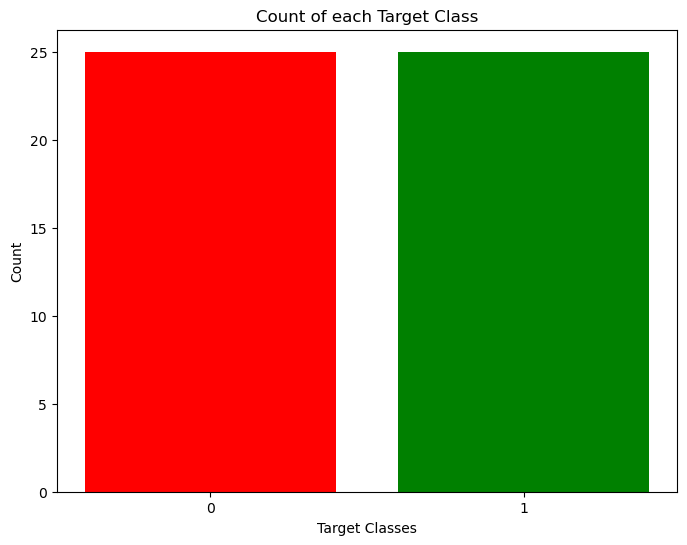

In [42]:
rcParams['figure.figsize'] = 8,6
plt.bar(df_vpn['Cond'].unique(), df_vpn['Cond'].value_counts(), color = ['red', 'green'])
plt.xticks([0, 1])
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.title('Count of each Target Class')
plt.show()

Let's check, whether the stressed people were stressed and the non-stressed were not:

Indicators of Stress: 

df['Cortisol_React']=(df.Cortisol_Max)-(df.cort_baseline) => positive

PANAS (Neg. Affect and Pos. Affect)

Here we identify participants whose stress markers go against their assigned condition: stressed participants (`Cond == 1`) that show a *decrease* in negative affect or a negative cortisol reaction.

In [43]:
print (df_vpn[((df_vpn['PANA_Delta_NA']<0) & (df_vpn.Cond==1))].vpn)
print (df_vpn.loc[(df_vpn['Cortisol_React']<0) & (df_vpn.Cond==1)].Cortisol_React)

1      3
29    42
35    48
Name: vpn, dtype: Int64
Series([], Name: Cortisol_React, dtype: float64)


Here the opposite case: control participants (`Cond == 0`) that nevertheless show a strong cortisol reaction or an increase in negative affect.

In [44]:
print (df_vpn.loc[(df_vpn['Cortisol_React']>5) & (df_vpn.Cond==0)].vpn)
print (df_vpn.loc[(df_vpn['PANA_Delta_NA']>0) & (df_vpn.Cond==0)].PANA_Delta_NA)

9     12
25    32
Name: vpn, dtype: Int64
38    4.0
42    1.0
Name: PANA_Delta_NA, dtype: float64


Here we plot the change in negative affect (PANAS) for every participant, labelled with the participant id and split by condition.

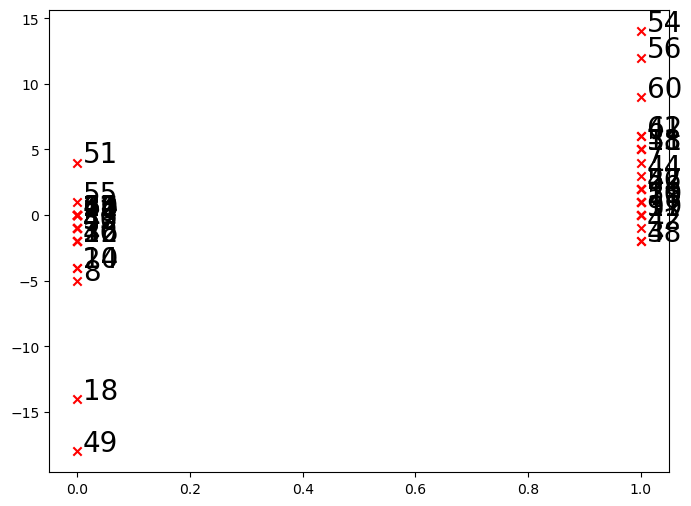

In [45]:
# simulating a pandas df['type'] column
types = df_vpn.vpn
y_coords = df_vpn.PANA_Delta_NA 
x_coords = df_vpn.Cond #

for i,type in enumerate(types):
    x = x_coords[i]
    y = y_coords[i]
    plt.scatter(x, y, marker='x', color='red')
    plt.text(x+0.01, y+0.01, type, fontsize=20)
plt.show() 

Here we plot the same per-participant scatter for the cortisol reaction.

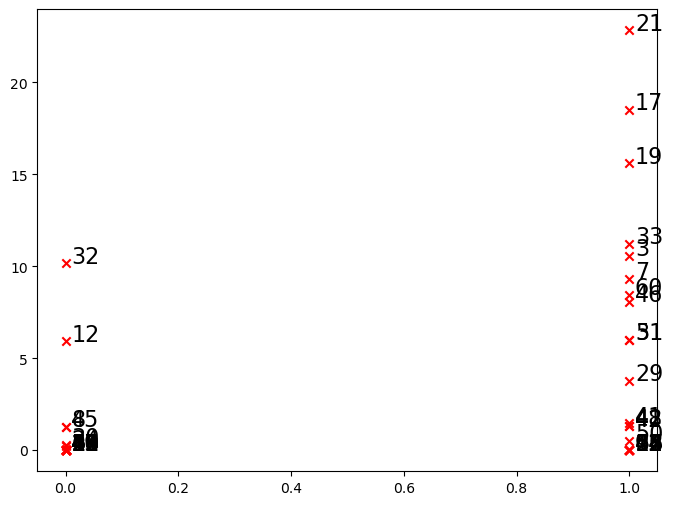

In [46]:
y_coords = df_vpn.Cortisol_React 

for i,type in enumerate(types):
    x = x_coords[i]
    y = y_coords[i]
    plt.scatter(x, y, marker='x', color='red')
    plt.text(x+0.01, y+0.01, type, fontsize=16)
plt.show() 

Here we compute the descriptive statistics (count, mean and standard deviation) of the main stress markers, separately for each condition.

In [47]:
df_vpn=df.groupby(['vpn']).mean(numeric_only=True).reset_index()
col_of_interest=['Cortisol_MinMax', 'Cortisol_React', 'sAA_React', 'PANA_Delta_NA', 'PANA_Delta_PA']
print (df_vpn.groupby(['Cond'])[col_of_interest].count())
print (df_vpn.groupby(['Cond'])[col_of_interest].mean())
print (df_vpn.groupby(['Cond'])[col_of_interest].std())

      Cortisol_MinMax  Cortisol_React  sAA_React  PANA_Delta_NA  PANA_Delta_PA
Cond                                                                          
0.0                25              25         25             25             25
1.0                25              25         25             25             25
      Cortisol_MinMax  Cortisol_React  sAA_React  PANA_Delta_NA  PANA_Delta_PA
Cond                                                                          
0.0          2.315891        0.766754   38.85852          -2.12           4.28
1.0          6.050480        5.001226   62.11512           3.04          -0.04
      Cortisol_MinMax  Cortisol_React  sAA_React  PANA_Delta_NA  PANA_Delta_PA
Cond                                                                          
0.0          2.116052        2.299566  40.893218       4.576389       5.420025
1.0          5.852318        6.568774  53.088755       4.036087       4.676894


/tmp/ipykernel_2960550/383039600.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_vpn=df.groupby(['vpn']).mean(numeric_only=True).reset_index()


Here we compute the descriptives of the log-transformed cortisol values (baseline, +1 min, +20 min) and the 20-minute cortisol change per condition.

In [48]:
col_of_interest=['LNCortisol_BL', 'LNCortisol_post1', 'LNCortisol_post20', 'cort_20_min']
print (df_vpn.groupby(['Cond'])[col_of_interest].count())
print (df_vpn.groupby(['Cond'])[col_of_interest].mean())
print (df_vpn.groupby(['Cond'])[col_of_interest].std())

      LNCortisol_BL  LNCortisol_post1  LNCortisol_post20  cort_20_min
Cond                                                                 
0.0              25                25                 25           25
1.0              25                25                 25           25
      LNCortisol_BL  LNCortisol_post1  LNCortisol_post20  cort_20_min
Cond                                                                 
0.0        2.075245          2.014581           1.933323     6.789896
1.0        2.223055          2.434174           2.529342    13.017200
      LNCortisol_BL  LNCortisol_post1  LNCortisol_post20  cort_20_min
Cond                                                                 
0.0        0.414708          0.491258           0.495946     4.052232
1.0        0.417722          0.370258           0.485013     6.824294


Here we compute the descriptives of the log-transformed salivary alpha-amylase (sAA) values per condition.

In [49]:
col_of_interest=['LNsAA_BL', 'LNsAA_post1', 'LNsAA_post20']
df_vpn.groupby(['Cond'])[col_of_interest].describe()

LNsAA_BL                                                              \
        count      mean       std       min       25%       50%       75%   
Cond                                                                        
0.0      25.0  4.460767  0.741772  2.669864  3.854606  4.798135  4.950723   
1.0      25.0  4.512720  0.973903  1.373716  4.099664  4.394091  5.099195   

               LNsAA_post1                                                    \
           max       count      mean       std       min       25%       50%   
Cond                                                                           
0.0   5.595083        25.0  4.821386  0.595173  3.519721  4.422088  4.927254   
1.0   6.004173        25.0  4.892771  0.942002  2.022871  4.479403  4.966823   

                         LNsAA_post20                                          \
           75%       max        count      mean       std       min       25%   
Cond                                                                            
0.0   5.249337  5.720810         25.0  4.572033  0.618478  3.395917  4.049522   
1.0   5.418360  6.421954         25.0  4.653435  0.892786  1.882514  4.142341   

                                    
           50%       75%       max  
Cond                                
0.0   4.716533  5.081044  5.480347  
1.0   4.751113  5.273143  5.889424